# Day-of-week seasonality in FCM and Pseudo demand

## Thresholds used

- **Upstream input filter:** FCM product-store series require at least 30 active days and 10 positive-demand days; Pseudo series require at least 120 active days and 30 positive-demand days.
- **Analysis period:** observations from 14 April 2025 onward; Monday–Saturday only.
- **Product-store eligibility:** at least 30 recent active days and at least 10 recent positive-demand days.
- **Eligible product-store-week:** at least 5 active open days and positive weekly total demand.
- **Product weekday profile:** all 6 weekdays must be present and at least 10 eligible stores must contribute.
- **Strong weekday seasonality:** weekday-profile CV `>= 0.10`, median cross-store correlation `>= 0.50`, and 2025–2026 period correlation `>= 0.50`; all three conditions are required.
- **ADI–CV² support:** at least 10 positive-demand days; ADI cutoff 1.32 and CV² cutoff 0.49.
- **Exclusion rule:** Sunday is omitted because only two stores regularly open on Sunday; this is a scope decision, not a seasonality threshold.

This notebook answers **“are there weekly seasonalities in both source groups?”** Here, weekly seasonality means a recurring **Monday–Saturday pattern inside the week**, not the annual ISO-week pattern studied in `01_01_cross_store_product_seasonality.ipynb`.

The analysis uses the common recent period from 14 April 2025 onward. Demand is normalized inside each product-store-week, which removes product scale and most annual level changes before weekdays are compared. Only product-store-weeks with at least five active open days and positive total demand are used. Sunday is excluded because regular stores are closed; the two Sunday-opening stores would otherwise define Sunday almost alone.

Evidence is required at three levels:

1. a non-flat weekday profile (`weekday_cv >= 0.10`),
2. agreement across stores (`median_store_correlation >= 0.50`), and
3. repetition between the 2025 and 2026 subperiods (`period_correlation >= 0.50`).

These are explicit descriptive thresholds, not a formal causal test. ADI–CV² is joined afterward to distinguish frequent from sparse daily demand.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

DATA_DIR_CANDIDATES = [
    Path("../../data/processed/transactions"),
    Path("data/processed/transactions"),
]
DATA_DIR = next((path for path in DATA_DIR_CANDIDATES if path.exists()), None)
if DATA_DIR is None or not any(DATA_DIR.glob("*.parquet")):
    raise FileNotFoundError(f"Daily parquet data not found; searched {DATA_DIR_CANDIDATES}")
DATA_GLOB = str(DATA_DIR / "*.parquet")

RECENT_START = "2025-04-14"
MIN_STORES = 10
MIN_ACTIVE_DAYS = 30
MIN_DEMAND_DAYS = 10
WEEKDAY_CV_THRESHOLD = 0.10
STORE_CORR_THRESHOLD = 0.50
PERIOD_CORR_THRESHOLD = 0.50
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49
SOURCE_ORDER = ["FCM", "Pseudo"]
SOURCE_COLORS = {"FCM": "#D45D45", "Pseudo": "#E3A83B"}
CLASS_ORDER = ["smooth", "erratic", "intermittent", "lumpy"]
CLASS_COLORS = {
    "smooth": "#2A9D8F", "erratic": "#E9C46A",
    "intermittent": "#457B9D", "lumpy": "#D62828",
}
WEEKDAY_LABELS = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})
con = duckdb.connect()
con.execute("PRAGMA threads=4")
display(con.execute(f"""
    SELECT min(DATE::DATE) AS first_date, max(DATE::DATE) AS last_date,
           count(DISTINCT ARTIKEL_ID) AS products,
           count(DISTINCT MARKT_ID) AS stores
    FROM read_parquet('{DATA_GLOB}')
""").fetchdf())

,first_date,last_date,products,stores
0,2023-07-22,2026-07-21,325,194


## 1. Construct comparable weekday profiles

A value of 1 means the day's demand equals that product-store-week's average active-day demand. For example, 1.20 means 20% above the same week's daily average. Weeks rather than entire histories are used as the normalization unit so an annual summer peak or launch ramp cannot masquerade as a weekday effect.

In [2]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE recent_daily AS
SELECT
    ARTIKEL_ID AS article_id,
    any_value(ARTIKEL_BEZ) AS product_name,
    CASE WHEN bool_or(is_fcm) THEN 'FCM' ELSE 'Pseudo' END AS source_class,
    MARKT_ID AS store_id,
    DATE::DATE AS sale_date,
    date_trunc('week', DATE::DATE)::DATE AS week_date,
    isodow(DATE::DATE) AS weekday,
    sum(ABVERKAUFTE_MENGE_KG) AS demand_kg
FROM read_parquet('{DATA_GLOB}')
WHERE is_active
  AND DATE::DATE >= DATE '{RECENT_START}'
  AND (is_fcm OR is_pseudo)
  AND isodow(DATE::DATE) BETWEEN 1 AND 6
GROUP BY ARTIKEL_ID, MARKT_ID, DATE::DATE,
         date_trunc('week', DATE::DATE), isodow(DATE::DATE)
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE weekday_normalized AS
WITH eligible_series AS (
    SELECT article_id, source_class, store_id
    FROM recent_daily
    GROUP BY article_id, source_class, store_id
    HAVING count(*) >= {MIN_ACTIVE_DAYS}
       AND count_if(demand_kg > 0) >= {MIN_DEMAND_DAYS}
), eligible_weeks AS (
    SELECT d.article_id, d.source_class, d.store_id, d.week_date,
           count(*) AS active_days, avg(d.demand_kg) AS mean_daily_demand
    FROM recent_daily d
    JOIN eligible_series e USING (article_id, source_class, store_id)
    GROUP BY d.article_id, d.source_class, d.store_id, d.week_date
    HAVING count(*) >= 5 AND sum(demand_kg) > 0
)
SELECT
    d.article_id, d.product_name, d.source_class, d.store_id,
    d.sale_date, d.week_date, d.weekday,
    d.demand_kg / nullif(w.mean_daily_demand, 0) AS normalized_demand,
    CASE WHEN d.sale_date < DATE '2026-01-01' THEN '2025' ELSE '2026' END AS subperiod
FROM recent_daily d
JOIN eligible_weeks w USING (article_id, source_class, store_id, week_date)
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE store_weekday_profile AS
SELECT article_id, any_value(product_name) AS product_name, source_class,
       store_id, weekday, avg(normalized_demand) AS profile_value,
       count(DISTINCT week_date) AS weeks
FROM weekday_normalized
GROUP BY article_id, source_class, store_id, weekday
""")
con.execute("""
CREATE OR REPLACE TEMP TABLE product_weekday_profile AS
SELECT article_id, any_value(product_name) AS product_name, source_class,
       weekday, median(profile_value) AS profile_value,
       count(DISTINCT store_id) AS stores
FROM store_weekday_profile
GROUP BY article_id, source_class, weekday
""")

profile_coverage = con.execute("""
    SELECT source_class, count(DISTINCT article_id) AS products,
           count(DISTINCT store_id) AS product_store_series,
           median(weeks) AS median_weeks_per_weekday
    FROM store_weekday_profile
    GROUP BY source_class ORDER BY source_class
""").fetchdf()
display(profile_coverage)

,source_class,products,product_store_series,median_weeks_per_weekday
0,FCM,28,191,26.0
1,Pseudo,296,193,39.0


## 2. Is the weekday pattern stable across stores and subperiods?

`weekday_cv` measures the amplitude of the six-day product profile. Store agreement correlates every store's six weekday values with its product-level median profile. Period correlation compares independently aggregated 2025 and 2026 weekday profiles. A product needs at least ten eligible stores and all six weekdays.

,source_class,eligible_products,strong_products,median_weekday_cv,median_store_correlation,median_period_correlation,strong_share_pct
0,FCM,23,11,0.296709,0.706024,0.990002,47.8
1,Pseudo,187,144,0.390296,0.863103,0.989393,77.0


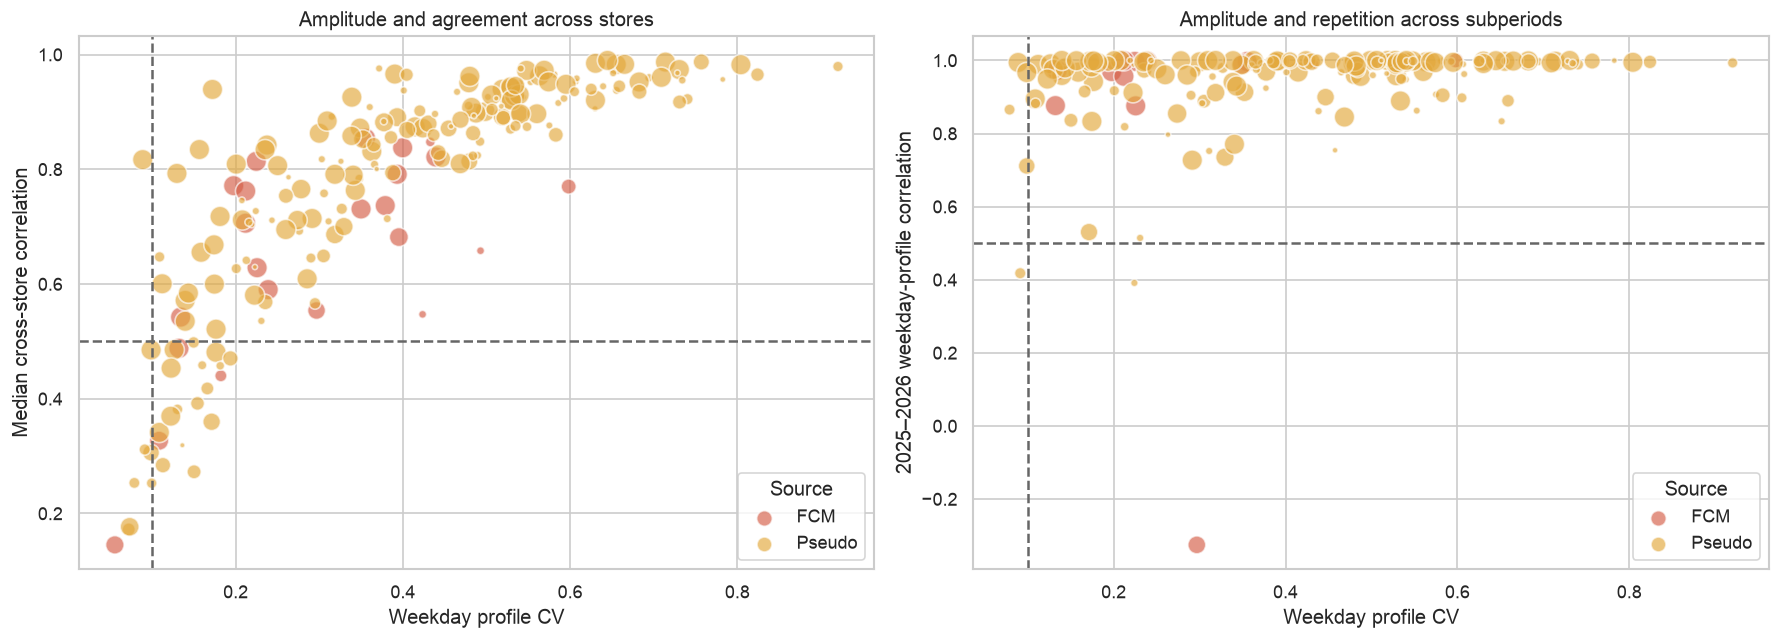

In [3]:
weekday_metrics = con.execute(f"""
WITH store_corr AS (
    SELECT s.article_id, s.store_id,
           corr(s.profile_value, p.profile_value) AS store_correlation,
           count(*) AS weekdays
    FROM store_weekday_profile s
    JOIN product_weekday_profile p USING (article_id, source_class, weekday)
    GROUP BY s.article_id, s.store_id
    HAVING count(*) = 6
), store_summary AS (
    SELECT article_id, count(*) AS eligible_stores,
           median(store_correlation) AS median_store_correlation
    FROM store_corr GROUP BY article_id
), period_profile AS (
    SELECT article_id, source_class, subperiod, weekday,
           median(normalized_demand) AS profile_value
    FROM weekday_normalized
    GROUP BY article_id, source_class, subperiod, weekday
), period_corr AS (
    SELECT a.article_id,
           corr(a.profile_value, b.profile_value) AS period_correlation,
           count(*) AS compared_weekdays
    FROM period_profile a JOIN period_profile b
      ON a.article_id = b.article_id AND a.weekday = b.weekday
     AND a.subperiod = '2025' AND b.subperiod = '2026'
    GROUP BY a.article_id
), profile_metrics AS (
    SELECT article_id, any_value(product_name) AS product_name,
           any_value(source_class) AS source_class,
           stddev_samp(profile_value) / nullif(avg(profile_value), 0) AS weekday_cv,
           max(profile_value) - min(profile_value) AS peak_trough_gap,
           arg_max(weekday, profile_value) AS peak_weekday,
           count(*) AS weekdays
    FROM product_weekday_profile GROUP BY article_id
)
SELECT p.*, s.eligible_stores, s.median_store_correlation,
       y.period_correlation, y.compared_weekdays
FROM profile_metrics p
JOIN store_summary s USING (article_id)
LEFT JOIN period_corr y USING (article_id)
WHERE p.weekdays = 6 AND s.eligible_stores >= {MIN_STORES}
""").fetchdf()

weekday_metrics["strong_weekday_seasonality"] = (
    (weekday_metrics.weekday_cv >= WEEKDAY_CV_THRESHOLD)
    & (weekday_metrics.median_store_correlation >= STORE_CORR_THRESHOLD)
    & (weekday_metrics.period_correlation >= PERIOD_CORR_THRESHOLD)
)
weekday_metrics["peak_day"] = weekday_metrics.peak_weekday.map(WEEKDAY_LABELS)
source_answer = (
    weekday_metrics.groupby("source_class")
    .agg(
        eligible_products=("article_id", "size"),
        strong_products=("strong_weekday_seasonality", "sum"),
        median_weekday_cv=("weekday_cv", "median"),
        median_store_correlation=("median_store_correlation", "median"),
        median_period_correlation=("period_correlation", "median"),
    )
    .reindex(SOURCE_ORDER)
)
source_answer["strong_share_pct"] = (
    100 * source_answer.strong_products / source_answer.eligible_products
).round(1)
display(source_answer.reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for source, group in weekday_metrics.groupby("source_class"):
    axes[0].scatter(
        group.weekday_cv, group.median_store_correlation,
        color=SOURCE_COLORS[source], alpha=0.65, label=source,
        s=np.clip(group.eligible_stores, 10, 150), edgecolor="white",
    )
    axes[1].scatter(
        group.weekday_cv, group.period_correlation,
        color=SOURCE_COLORS[source], alpha=0.65, label=source,
        s=np.clip(group.eligible_stores, 10, 150), edgecolor="white",
    )
for ax in axes:
    ax.axvline(WEEKDAY_CV_THRESHOLD, color="0.4", linestyle="--")
    ax.legend(title="Source")
    ax.set_xlabel("Weekday profile CV")
axes[0].axhline(STORE_CORR_THRESHOLD, color="0.4", linestyle="--")
axes[1].axhline(PERIOD_CORR_THRESHOLD, color="0.4", linestyle="--")
axes[0].set_ylabel("Median cross-store correlation")
axes[1].set_ylabel("2025–2026 weekday-profile correlation")
axes[0].set_title("Amplitude and agreement across stores")
axes[1].set_title("Amplitude and repetition across subperiods")
fig.tight_layout()
plt.show()

## 3. What do the weekday profiles look like?
1. Uses active Monday–Saturday observations from 14 April 2025 onward. Sunday is intentionally
     excluded because only two stores regularly open.

  2. Requires each product-store series to have at least 30 active days and 10 demand days.
  3. Retains product-store-weeks with at least five active days and positive weekly demand.
  4. Normalizes each daily value by that product-store-week’s mean active-day demand.
  5. Averages normalized demand by weekday for each store, then takes the median across stores to form
     a six-day product profile.

  6. Requires all six weekdays and at least ten eligible stores.
  7. Classifies strong weekday seasonality only when all three conditions hold:
      - weekday-profile CV ≥ 0.10;
      - median store-to-product-profile correlation ≥ 0.50;
      - 2025-versus-2026 weekday-profile correlation ≥ 0.50.


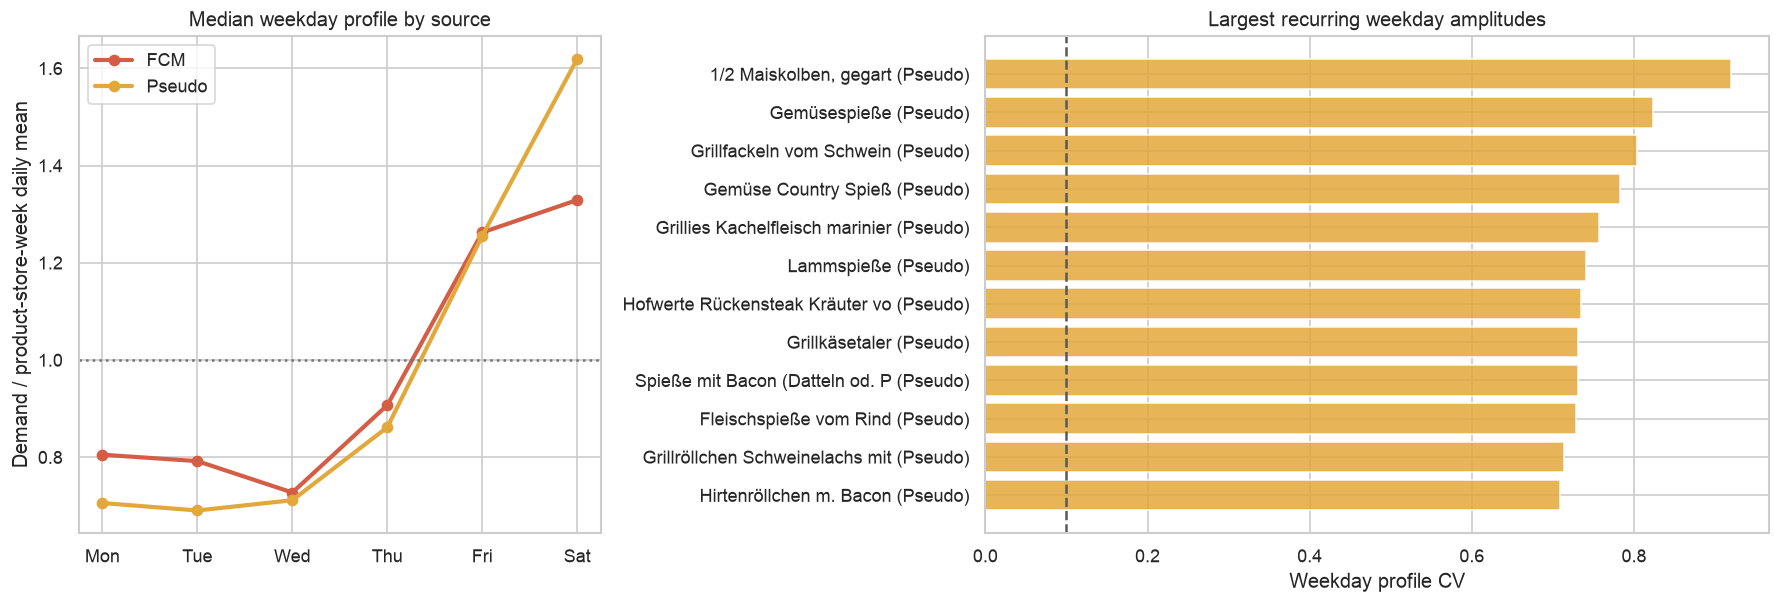

,article_id,product_name,source_class,eligible_stores,weekday_cv,peak_trough_gap,peak_day,median_store_correlation,period_correlation,strong_weekday_seasonality
0,1023161,"1/2 Maiskolben, gegart",Pseudo,40,0.920216,2.222201,Sat,0.979271,0.993314,True
1,563280,Gemüsespieße,Pseudo,68,0.823996,2.094567,Sat,0.965032,0.995912,True
2,317200,Grillfackeln vom Schwein,Pseudo,178,0.804137,1.991151,Sat,0.982354,0.994867,True
3,1298912,Gemüse Country Spieß,Pseudo,13,0.782498,1.899844,Sat,0.956708,0.999585,True
4,317204,"Grillies Kachelfleisch mariniert, vom Schwein",Pseudo,96,0.756828,1.870225,Sat,0.987202,0.998328,True
5,747681,Lammspieße,Pseudo,46,0.740301,1.767754,Sat,0.922360,0.989021,True
6,1203733,Hofwerte Rückensteak Kräuter vom Schwein,Pseudo,22,0.734049,1.751990,Sat,0.955251,0.992399,True
7,748734,Spieße mit Bacon (Datteln od. Pflaume - Aprikose),Pseudo,164,0.730538,1.801821,Sat,0.973924,0.999928,True
8,1101763,Fleischspieße vom Rind,Pseudo,12,0.728264,1.780654,Sat,0.968076,0.997779,True
9,318149,"Grillröllchen Schweinelachs mit Käsefüllung, m...",Pseudo,189,0.713953,1.782197,Sat,0.986962,0.997851,True


In [4]:
weekday_profiles = con.execute("SELECT * FROM product_weekday_profile").fetchdf()
eligible_profile = weekday_profiles.merge(
    weekday_metrics[["article_id", "strong_weekday_seasonality"]],
    on="article_id", how="inner",
)
source_profile = (
    eligible_profile.groupby(["source_class", "weekday"], as_index=False)
    .profile_value.median()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), gridspec_kw={"width_ratios": [1, 1.5]})
for source in SOURCE_ORDER:
    part = source_profile[source_profile.source_class == source]
    axes[0].plot(
        part.weekday, part.profile_value, marker="o", linewidth=2.5,
        color=SOURCE_COLORS[source], label=source,
    )
axes[0].axhline(1, color="0.45", linestyle=":")
axes[0].set_xticks(list(WEEKDAY_LABELS), list(WEEKDAY_LABELS.values()))
axes[0].set_ylabel("Demand / product-store-week daily mean")
axes[0].set_title("Median weekday profile by source")
axes[0].legend()

strongest = weekday_metrics.nlargest(12, "weekday_cv").copy()
strongest["label"] = strongest.product_name.str.slice(0, 31) + " (" + strongest.source_class + ")"
strongest = strongest.sort_values("weekday_cv")
axes[1].barh(
    strongest.label, strongest.weekday_cv,
    color=strongest.source_class.map(SOURCE_COLORS), alpha=0.85,
)
axes[1].axvline(WEEKDAY_CV_THRESHOLD, color="0.35", linestyle="--")
axes[1].set_xlabel("Weekday profile CV")
axes[1].set_title("Largest recurring weekday amplitudes")
fig.tight_layout()
plt.show()

display(
    weekday_metrics.sort_values(
        ["strong_weekday_seasonality", "weekday_cv"], ascending=False
    )[[
        "article_id", "product_name", "source_class", "eligible_stores",
        "weekday_cv", "peak_trough_gap", "peak_day",
        "median_store_correlation", "period_correlation",
        "strong_weekday_seasonality",
    ]].head(25).reset_index(drop=True)
)

## 4. ADI–CV² context

ADI–CV² is computed from the same daily product-store series over their full retained histories. The first view asks whether products passing the weekly-seasonality rule are disproportionately smooth/erratic. The second checks the three annual families from `01_01`: annual family membership does not automatically imply a strong day-of-week effect.

,source_class,weekday_status,demand_class,product_store_series,median_ADI,median_CV2,share,share_pct
0,FCM,Does not pass all thresholds,erratic,18,1.248932,0.615148,0.012940,1.3
1,FCM,Does not pass all thresholds,intermittent,529,5.325581,0.363263,0.380302,38.0
2,FCM,Does not pass all thresholds,lumpy,839,3.046729,0.665529,0.603163,60.3
3,FCM,Does not pass all thresholds,smooth,5,1.112782,0.376358,0.003595,0.4
4,FCM,Strong weekday pattern,erratic,99,1.185315,0.566975,0.058824,5.9
5,FCM,Strong weekday pattern,intermittent,568,2.438978,0.386967,0.337493,33.7
6,FCM,Strong weekday pattern,lumpy,842,2.780220,0.734401,0.500297,50.0
7,FCM,Strong weekday pattern,smooth,174,1.182257,0.414114,0.103387,10.3
8,Pseudo,Does not pass all thresholds,erratic,214,1.007761,0.794423,0.067465,6.7
9,Pseudo,Does not pass all thresholds,intermittent,667,6.840909,0.394159,0.210277,21.0


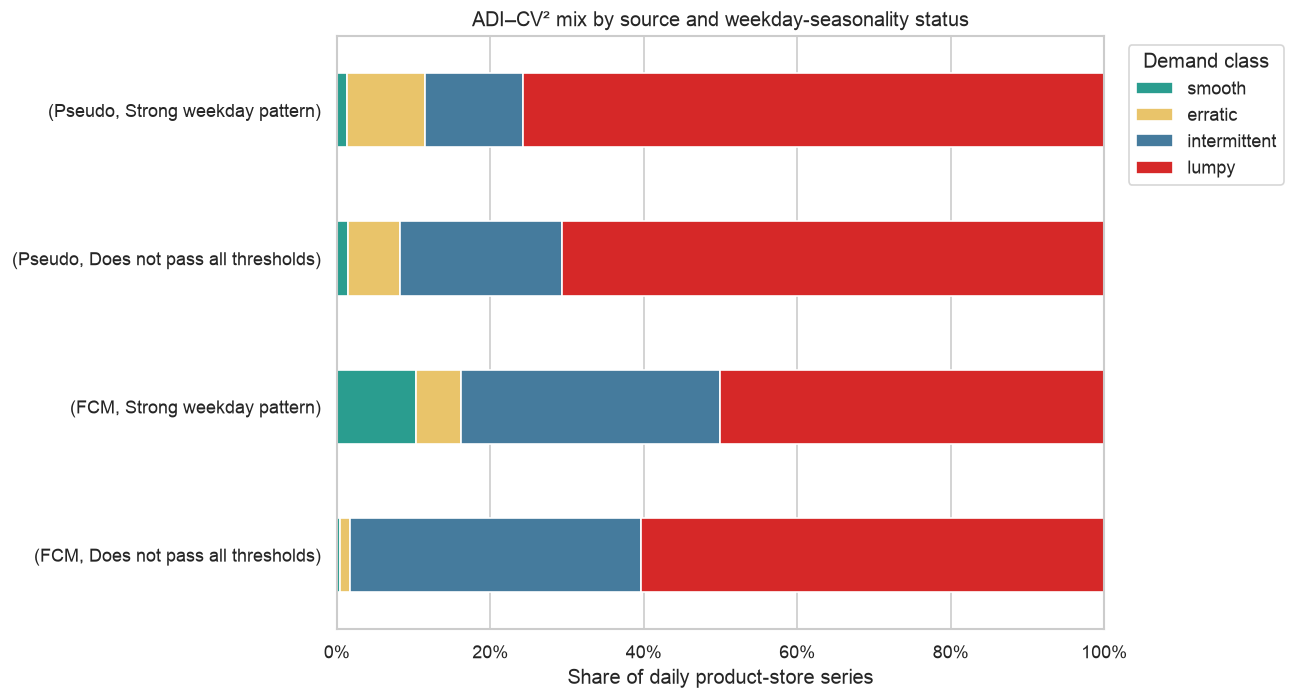

In [5]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE daily_adi_cv2 AS
WITH series AS (
    SELECT ARTIKEL_ID AS article_id, MARKT_ID AS store_id,
           CASE WHEN bool_or(is_fcm) THEN 'FCM' ELSE 'Pseudo' END AS source_class,
           count(*) AS active_days,
           count_if(ABVERKAUFTE_MENGE_KG > 0) AS demand_days,
           avg(CASE WHEN ABVERKAUFTE_MENGE_KG > 0 THEN ABVERKAUFTE_MENGE_KG END) AS mean_positive,
           var_samp(CASE WHEN ABVERKAUFTE_MENGE_KG > 0 THEN ABVERKAUFTE_MENGE_KG END) AS var_positive
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active AND (is_fcm OR is_pseudo)
    GROUP BY ARTIKEL_ID, MARKT_ID
), metrics AS (
    SELECT *, active_days / nullif(demand_days, 0) AS ADI,
           CASE WHEN demand_days > 1 AND mean_positive > 0
                THEN var_positive / (mean_positive * mean_positive)
                WHEN demand_days = 1 THEN 0.0 END AS CV2
    FROM series WHERE demand_days >= {MIN_DEMAND_DAYS}
)
SELECT *, CASE
    WHEN ADI < {ADI_CUTOFF} AND CV2 < {CV2_CUTOFF} THEN 'smooth'
    WHEN ADI < {ADI_CUTOFF} AND CV2 >= {CV2_CUTOFF} THEN 'erratic'
    WHEN ADI >= {ADI_CUTOFF} AND CV2 < {CV2_CUTOFF} THEN 'intermittent'
    WHEN ADI >= {ADI_CUTOFF} AND CV2 >= {CV2_CUTOFF} THEN 'lumpy'
END AS demand_class
FROM metrics
""")

status = weekday_metrics[["article_id", "source_class", "strong_weekday_seasonality"]].copy()
status["weekday_status"] = np.where(
    status.strong_weekday_seasonality, "Strong weekday pattern", "Does not pass all thresholds"
)
con.register("weekday_status", status[["article_id", "source_class", "weekday_status"]])
status_adi = con.execute("""
    SELECT s.source_class, s.weekday_status, a.demand_class,
           count(*) AS product_store_series,
           median(a.ADI) AS median_ADI, median(a.CV2) AS median_CV2
    FROM daily_adi_cv2 a
    JOIN weekday_status s USING (article_id, source_class)
    WHERE a.demand_class IS NOT NULL
    GROUP BY s.source_class, s.weekday_status, a.demand_class
""").fetchdf()
status_adi["share"] = status_adi.groupby(
    ["source_class", "weekday_status"]
).product_store_series.transform(lambda x: x / x.sum())
display(
    status_adi.assign(share_pct=lambda x: (100 * x.share).round(1))
    .sort_values(["source_class", "weekday_status", "demand_class"])
    .reset_index(drop=True)
)

plot_data = status_adi.pivot_table(
    index=["source_class", "weekday_status"], columns="demand_class",
    values="share", fill_value=0,
).reindex(columns=CLASS_ORDER, fill_value=0)
ax = plot_data.plot(
    kind="barh", stacked=True, figsize=(11, 6),
    color=[CLASS_COLORS[c] for c in CLASS_ORDER],
)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_xlabel("Share of daily product-store series")
ax.set_ylabel("")
ax.set_title("ADI–CV² mix by source and weekday-seasonality status")
ax.legend(title="Demand class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [6]:
PRODUCT_GROUPS = {
    "Barbecue / summer": [317123, 317204, 318149, 629118, 329560, 317164, 748734, 317181, 317200, 627050, 317157, 317119],
    "Christmas roasts": [316708, 911705, 316791, 318159],
    "Easter lamb": [317043, 317033, 317004],
}
family_lookup = {
    article_id: family for family, ids in PRODUCT_GROUPS.items() for article_id in ids
}
family_weekday = weekday_metrics[
    weekday_metrics.article_id.isin(family_lookup)
].copy()
family_weekday["annual_family"] = family_weekday.article_id.map(family_lookup)

family_adi_rows = con.execute("SELECT * FROM daily_adi_cv2").fetchdf()
family_adi_rows = family_adi_rows[family_adi_rows.article_id.isin(family_lookup)].copy()
family_adi_rows["annual_family"] = family_adi_rows.article_id.map(family_lookup)
family_product_adi = (
    family_adi_rows.groupby(["annual_family", "article_id"])
    .agg(median_ADI=("ADI", "median"), median_CV2=("CV2", "median"),
         smooth_or_erratic_share=("demand_class", lambda x: x.isin(["smooth", "erratic"]).mean()))
    .reset_index()
)
family_weekday = family_weekday.merge(
    family_product_adi, on=["annual_family", "article_id"], how="left"
)
display(
    family_weekday[[
        "annual_family", "article_id", "product_name", "weekday_cv",
        "median_store_correlation", "period_correlation",
        "strong_weekday_seasonality", "median_ADI", "median_CV2",
        "smooth_or_erratic_share",
    ]].sort_values(["annual_family", "weekday_cv"], ascending=[True, False])
    .reset_index(drop=True)
)

,annual_family,article_id,product_name,weekday_cv,median_store_correlation,period_correlation,strong_weekday_seasonality,median_ADI,median_CV2,smooth_or_erratic_share
0,Barbecue / summer,317200,Grillfackeln vom Schwein,0.804137,0.982354,0.994867,True,3.918103,0.952354,0.000000
1,Barbecue / summer,317204,"Grillies Kachelfleisch mariniert, vom Schwein",0.756828,0.987202,0.998328,True,2.065909,0.980037,0.144330
2,Barbecue / summer,748734,Spieße mit Bacon (Datteln od. Pflaume - Aprikose),0.730538,0.973924,0.999928,True,3.820058,0.726603,0.000000
3,Barbecue / summer,318149,"Grillröllchen Schweinelachs mit Käsefüllung, m...",0.713953,0.986962,0.997851,True,1.887853,1.045742,0.126316
4,Barbecue / summer,317157,"Bauchscheiben gewürzt, vom Schwein",0.665088,0.983018,0.998285,True,1.564544,1.369457,0.256545
5,Barbecue / summer,317123,"Nackensteak mariniert, vom Schwein",0.644673,0.989838,0.999278,True,1.186684,1.596527,0.753927
6,Barbecue / summer,317119,Schweinerückensteaks mariniert,0.630309,0.984803,0.998172,True,1.350669,1.618268,0.460733
7,Barbecue / summer,317181,"Rinder-Steak mariniert, aus der Keule",0.625168,0.939782,0.997894,True,3.988070,0.947594,0.018519
8,Barbecue / summer,317164,Grillschnecken Grobe Schweinebratwurst im Sait...,0.547853,0.972458,0.998623,True,1.843813,1.009887,0.137566
9,Christmas roasts,911705,Frankreich Rinderrouladen Oberschale,0.540905,0.975731,0.998063,True,1.504967,2.849736,0.050000


## 5. Automatically computed answer

In [7]:
lines = []
for source in SOURCE_ORDER:
    row = source_answer.loc[source]
    lines.append(
        f"- **{source}:** {int(row.strong_products)} of {int(row.eligible_products)} eligible products "
        f"({row.strong_share_pct:.1f}%) pass all three weekday-seasonality thresholds."
    )
family_pass = (
    family_weekday.groupby("annual_family").strong_weekday_seasonality
    .agg(["sum", "count"])
)
family_lines = [
    f"- **{family}:** {int(row['sum'])} of {int(row['count'])} available members pass the weekday rule."
    for family, row in family_pass.iterrows()
]
display(Markdown(
    "**Answer by source group**\n\n" + "\n".join(lines)
    + "\n\n**Relation to the three annual families**\n\n" + "\n".join(family_lines)
    + "\n\nA product can have strong annual seasonality without a recurring weekday pattern, and vice versa. "
      "ADI–CV² describes demand density and positive-demand variability, so it supports but does not define either seasonality concept."
))

**Answer by source group**

- **FCM:** 11 of 23 eligible products (47.8%) pass all three weekday-seasonality thresholds.
- **Pseudo:** 144 of 187 eligible products (77.0%) pass all three weekday-seasonality thresholds.

**Relation to the three annual families**

- **Barbecue / summer:** 9 of 9 available members pass the weekday rule.
- **Christmas roasts:** 4 of 4 available members pass the weekday rule.
- **Easter lamb:** 3 of 3 available members pass the weekday rule.

A product can have strong annual seasonality without a recurring weekday pattern, and vice versa. ADI–CV² describes demand density and positive-demand variability, so it supports but does not define either seasonality concept.

## Interpretation limits

- Normalizing inside a product-store-week greatly reduces annual-level confounding but does not remove promotions scheduled on particular weekdays.
- Holidays and closed Sundays remain in the calendar data but are excluded here via `is_active`; weeks with fewer than five active days are excluded.
- FCM has a shorter history, so its 2025–2026 period correlation is based on unequal subperiod lengths.
- The thresholds define a conservative descriptive screen. Products just below a boundary should not be interpreted as categorically non-seasonal.